In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the data
scada = pd.read_csv('data/raw/raw_scada.csv')
wiring = pd.read_csv('data/raw/wiring_plan.csv')

print(f"SCADA shape: {scada.shape}")
print(f"Wiring shape: {wiring.shape}")
print("\nSCADA columns:", scada.columns.tolist())
print("Wiring columns:", wiring.columns.tolist())

SCADA shape: (1740, 8)
Wiring shape: (12, 5)

SCADA columns: ['timestamp', 'inverter_id', 'string_id', 'power_kw', 'voltage_v', 'current_a', 'irradiance_wm2', 'temperature_c']
Wiring columns: ['string_id', 'inverter_id', 'string_length', 'orientation', 'tilt_deg']


In [13]:
scada.head()

,timestamp,inverter_id,string_id,power_kw,voltage_v,current_a,irradiance_wm2,temperature_c
0,2025-01-01 00:00:00,INV_01,STR_01,28.973713,644.777539,36.186916,1100.000000,33.933450
1,2025-01-01 00:00:00,INV_02,STR_02,23.893886,641.558914,22.381177,604.035109,26.856757
2,2025-01-01 00:00:00,INV_03,STR_03,23.541576,653.502608,35.832137,532.544083,28.991066
3,2025-01-01 00:00:00,INV_04,STR_04,29.003706,708.093915,37.614895,321.362376,22.262811
4,2025-01-01 00:00:00,INV_01,STR_05,23.126773,603.632343,31.936411,1100.000000,26.560615


In [7]:
wiring.head()

,string_id,inverter_id,string_length,orientation,tilt_deg
0,STR_01,INV_01,24,South,35
1,STR_02,INV_01,24,South,35
2,STR_03,INV_01,24,South,35
3,STR_04,INV_02,24,South,35
4,STR_05,INV_02,24,South,35


In [8]:
# Basic statistics
print(scada.describe())

          power_kw    voltage_v    current_a  irradiance_wm2  temperature_c
count  1740.000000  1740.000000  1740.000000     1740.000000    1740.000000
mean     22.564880   650.040342    37.737560      581.873599      25.207189
std       9.406820    49.836491     5.843732      287.443076       8.181988
min       0.000000   500.000000    18.939777        0.000000       5.000000
25%      17.145973   616.828424    33.840879      374.546180      19.699183
50%      23.021216   650.043336    37.914892      580.972875      25.094972
75%      28.955545   683.586018    41.745253      799.294855      30.855550
max      45.000000   800.000000    50.000000     1100.000000      45.000000


In [14]:
# Fix timestamp format
scada['timestamp'] = pd.to_datetime(scada['timestamp'])
print("Timestamp type fixed!")

scada.head()

Timestamp type fixed!


,timestamp,inverter_id,string_id,power_kw,voltage_v,current_a,irradiance_wm2,temperature_c
0,2025-01-01,INV_01,STR_01,28.973713,644.777539,36.186916,1100.000000,33.933450
1,2025-01-01,INV_02,STR_02,23.893886,641.558914,22.381177,604.035109,26.856757
2,2025-01-01,INV_03,STR_03,23.541576,653.502608,35.832137,532.544083,28.991066
3,2025-01-01,INV_04,STR_04,29.003706,708.093915,37.614895,321.362376,22.262811
4,2025-01-01,INV_01,STR_05,23.126773,603.632343,31.936411,1100.000000,26.560615


In [17]:
# Check the actual timestamp with full details
print("First 5 timestamps with full info:")
print(scada['timestamp'].head(5))

print("\nData type of timestamp:", scada['timestamp'].dtype)

First 5 timestamps with full info:
0   2025-01-01
1   2025-01-01
2   2025-01-01
3   2025-01-01
4   2025-01-01
Name: timestamp, dtype: datetime64[us]

Data type of timestamp: datetime64[us]


In [18]:
# Force showing time in display
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

scada.head()

,timestamp,inverter_id,string_id,power_kw,voltage_v,current_a,irradiance_wm2,temperature_c
0,2025-01-01,INV_01,STR_01,28.973713,644.777539,36.186916,1100.000000,33.933450
1,2025-01-01,INV_02,STR_02,23.893886,641.558914,22.381177,604.035109,26.856757
2,2025-01-01,INV_03,STR_03,23.541576,653.502608,35.832137,532.544083,28.991066
3,2025-01-01,INV_04,STR_04,29.003706,708.093915,37.614895,321.362376,22.262811
4,2025-01-01,INV_01,STR_05,23.126773,603.632343,31.936411,1100.000000,26.560615


In [19]:
# Better display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Show clean preview
scada.head(10)

,timestamp,inverter_id,string_id,power_kw,voltage_v,current_a,irradiance_wm2,temperature_c
0,2025-01-01,INV_01,STR_01,28.97,644.78,36.19,1100.00,33.93
1,2025-01-01,INV_02,STR_02,23.89,641.56,22.38,604.04,26.86
2,2025-01-01,INV_03,STR_03,23.54,653.50,35.83,532.54,28.99
3,2025-01-01,INV_04,STR_04,29.00,708.09,37.61,321.36,22.26
4,2025-01-01,INV_01,STR_05,23.13,603.63,31.94,1100.00,26.56
5,2025-01-01,INV_02,STR_06,23.13,661.92,34.91,278.00,29.30
6,2025-01-01,INV_03,STR_07,5.65,698.76,47.18,471.35,20.37
7,2025-01-01,INV_04,STR_08,31.14,675.05,41.99,724.75,24.38
8,2025-01-01,INV_01,STR_09,21.24,659.48,32.45,780.06,24.53
9,2025-01-01,INV_02,STR_10,29.34,700.05,28.41,887.38,31.61


In [20]:
scada[['timestamp', 'string_id', 'inverter_id', 'power_kw', 'irradiance_wm2']].head(15)

,timestamp,string_id,inverter_id,power_kw,irradiance_wm2
0,2025-01-01 00:00:00,STR_01,INV_01,28.97,1100.00
1,2025-01-01 00:00:00,STR_02,INV_02,23.89,604.04
2,2025-01-01 00:00:00,STR_03,INV_03,23.54,532.54
3,2025-01-01 00:00:00,STR_04,INV_04,29.00,321.36
4,2025-01-01 00:00:00,STR_05,INV_01,23.13,1100.00
5,2025-01-01 00:00:00,STR_06,INV_02,23.13,278.00
6,2025-01-01 00:00:00,STR_07,INV_03,5.65,471.35
7,2025-01-01 00:00:00,STR_08,INV_04,31.14,724.75
8,2025-01-01 00:00:00,STR_09,INV_01,21.24,780.06
9,2025-01-01 00:00:00,STR_10,INV_02,29.34,887.38


In [15]:
# Check how many records per string
print(scada['string_id'].value_counts().head())
print("\nUnique inverters:", scada['inverter_id'].nunique())

string_id
STR_01    145
STR_02    145
STR_03    145
STR_04    145
STR_05    145
Name: count, dtype: int64

Unique inverters: 4


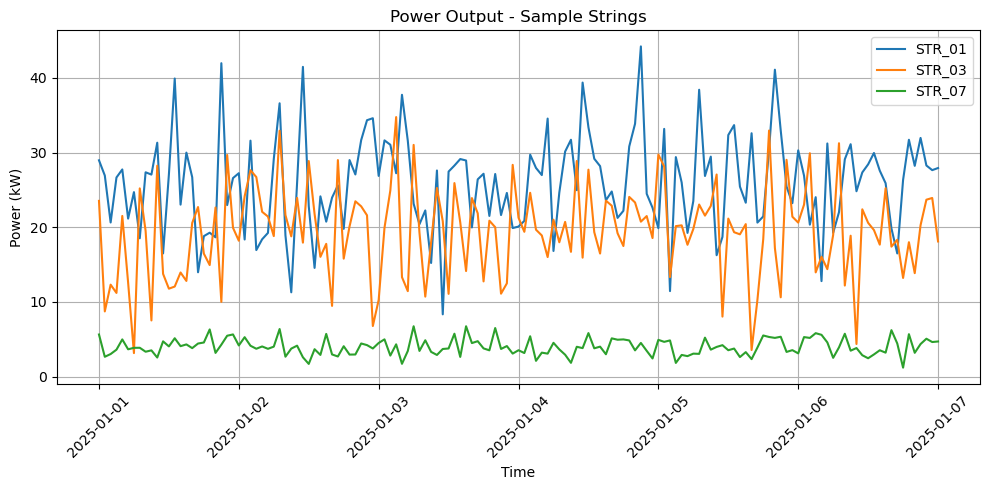

In [16]:
# Quick visualization
plt.figure(figsize=(10, 5))
sample_strings = ['STR_01', 'STR_03', 'STR_07']
for s in sample_strings:
    data = scada[scada['string_id'] == s]
    plt.plot(data['timestamp'], data['power_kw'], label=s)

plt.title('Power Output - Sample Strings')
plt.xlabel('Time')
plt.ylabel('Power (kW)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()